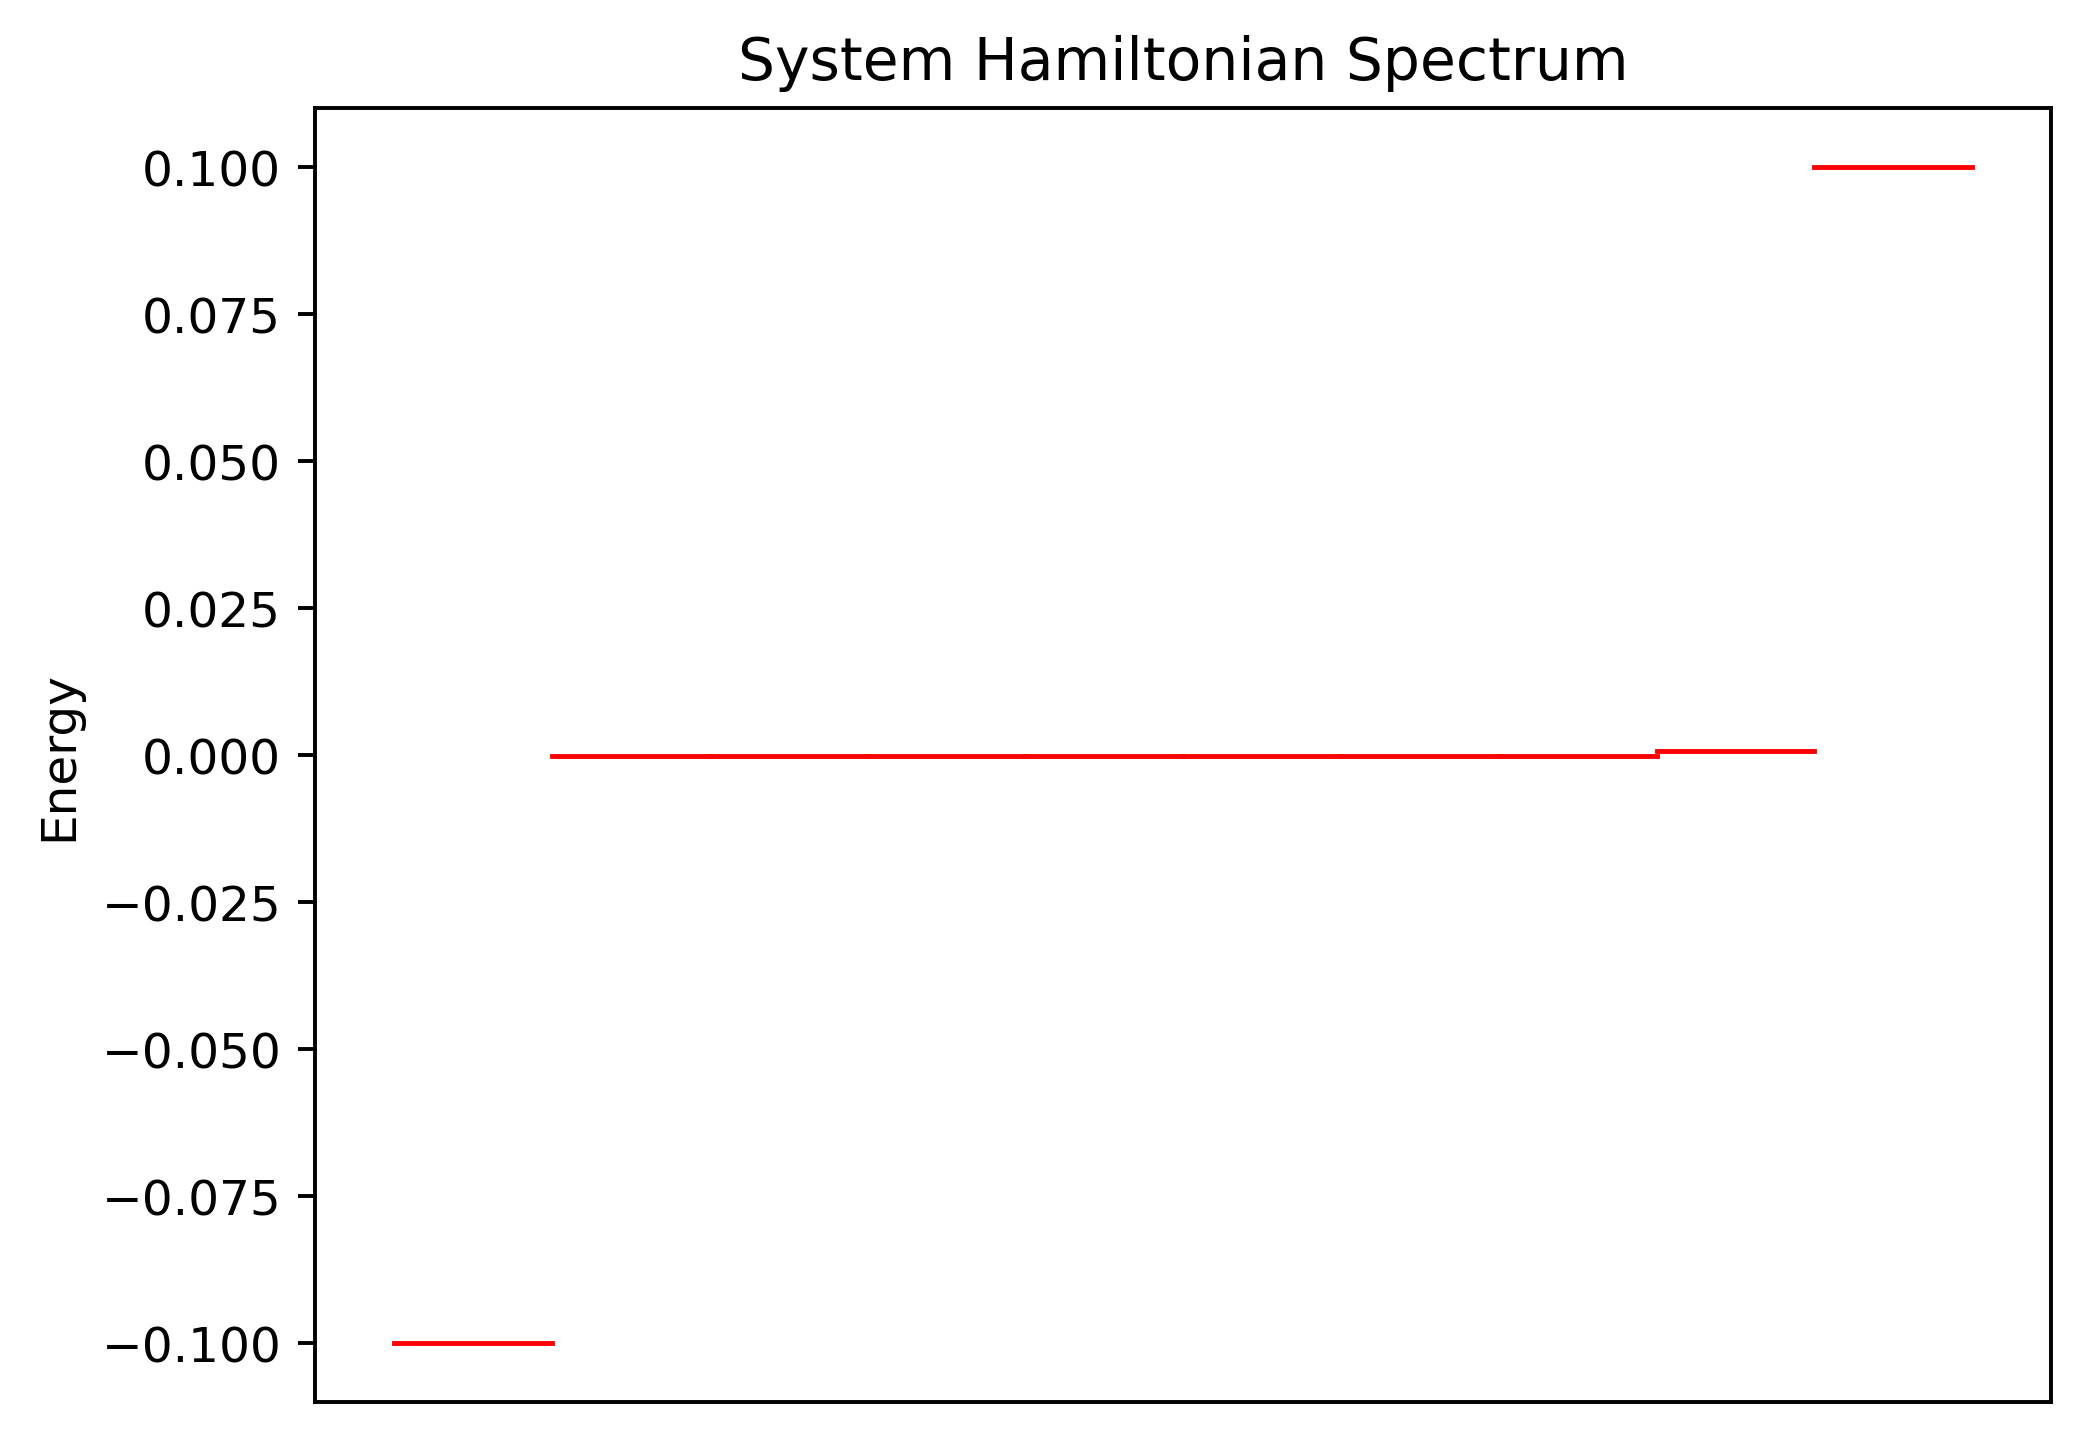

trace= 0.9999999999999997


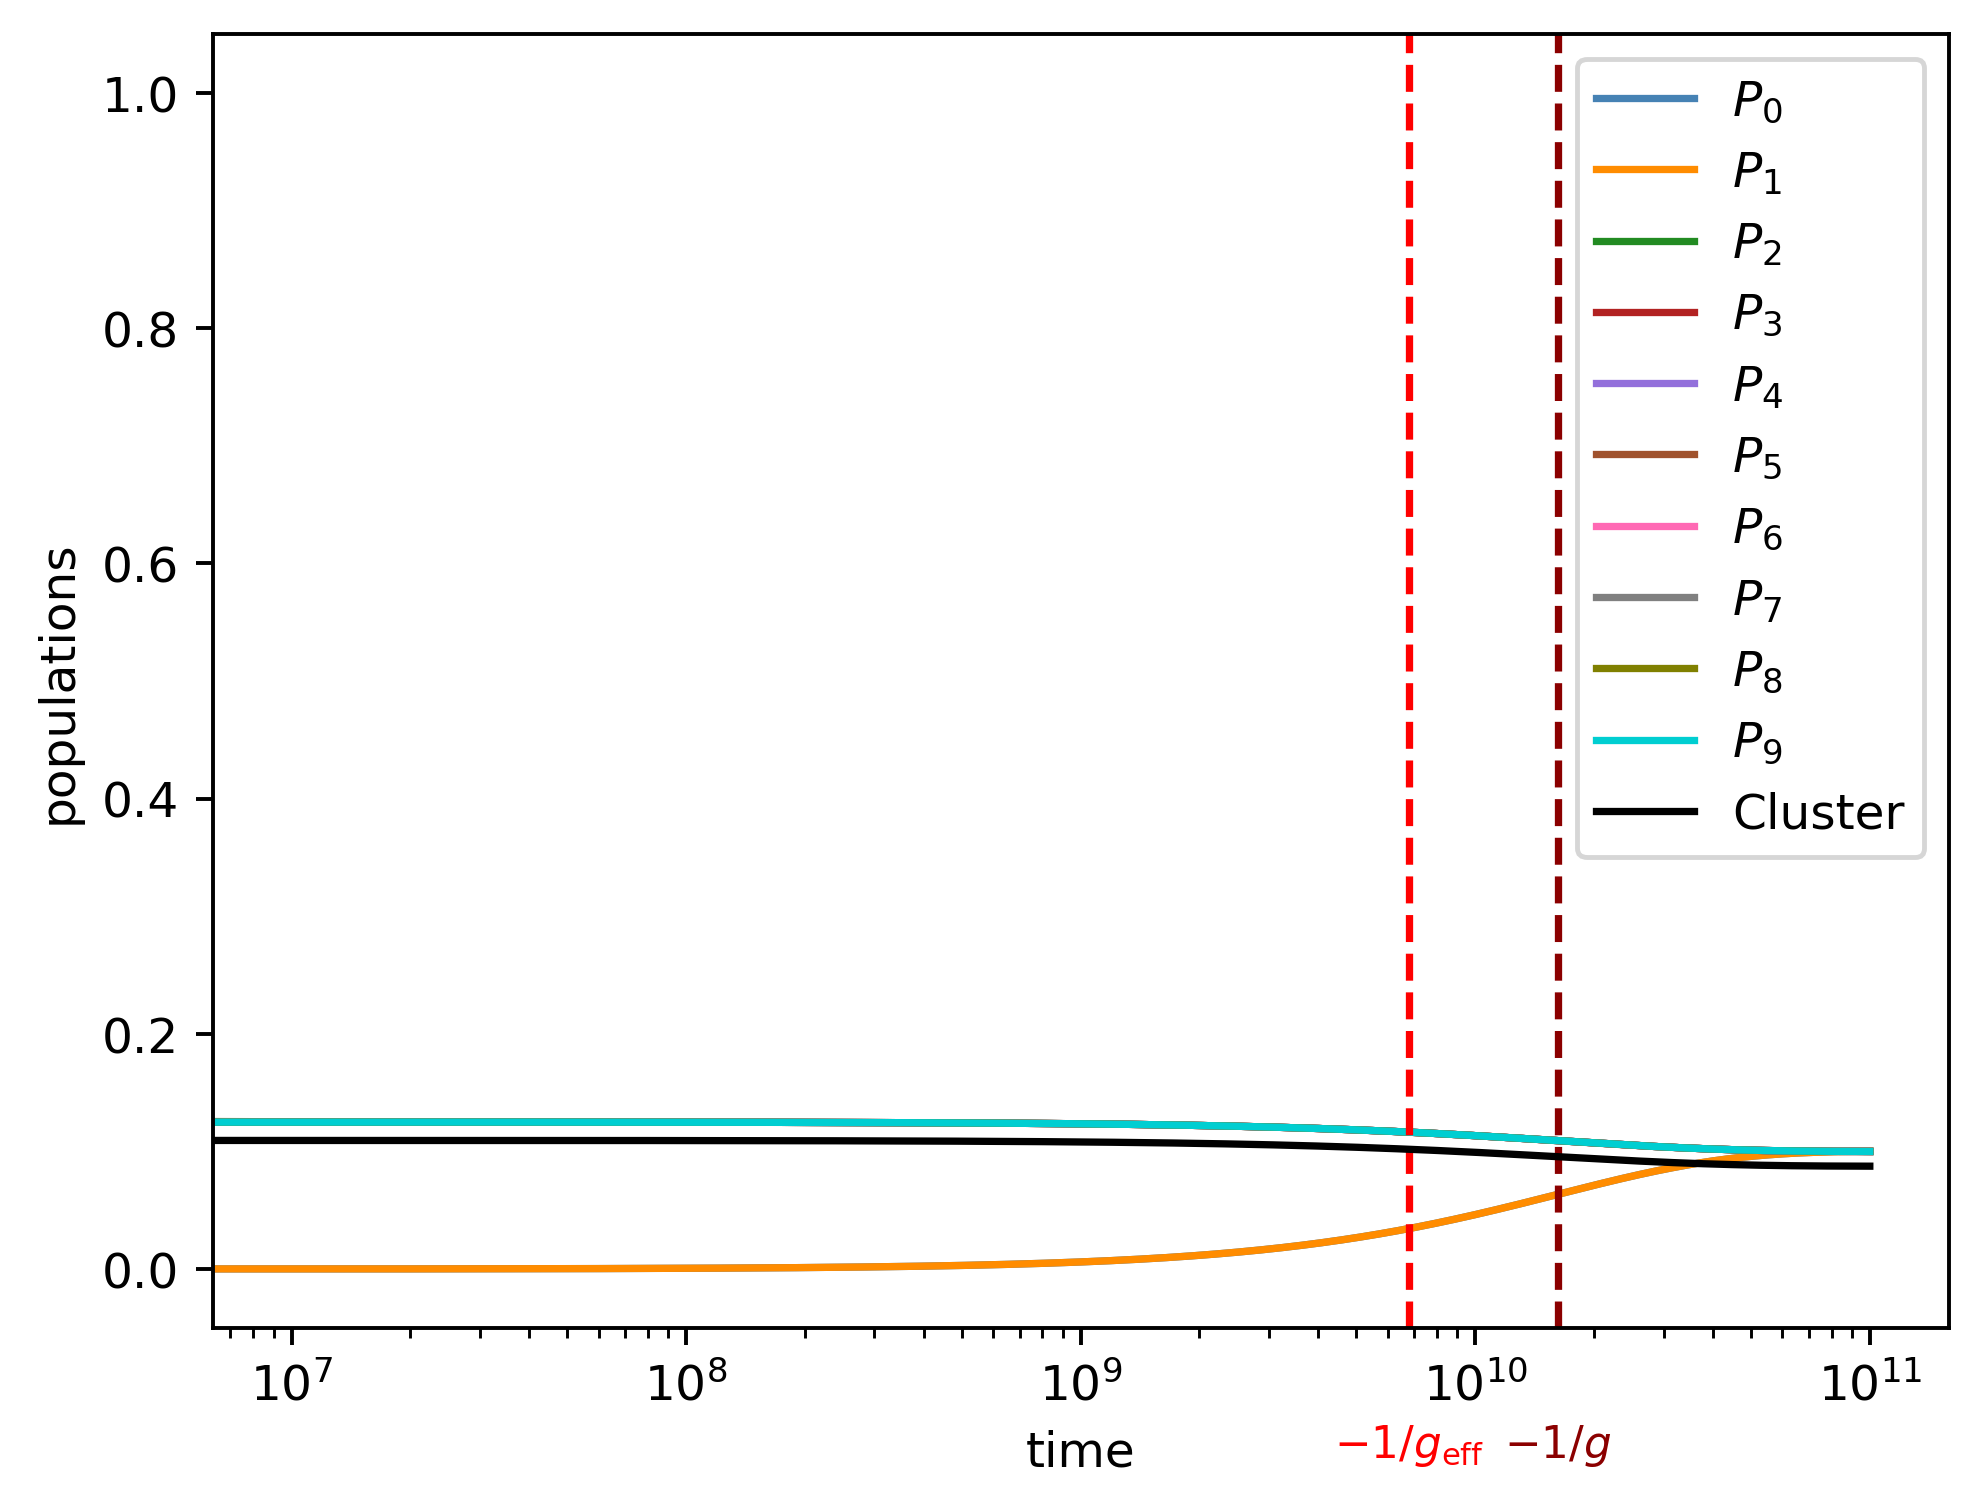

In [56]:
%matplotlib inline
import numpy as np
from utils import _build_redfield_numba, build_redfield_tensor, evolve_density_matrix
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from matplotlib.colors import LogNorm
plt.rcParams['figure.dpi']=350

#coupling params
J_max = 1
power = 3 #power for coupling matrix/system hamiltonain - 3 for dipole-dipole like model
J=0.1
eps=1e-4
#bath params- assuming 3 decoupled ohmic baths
alpha_list=np.array(1e-6*np.ones(10))
wc_list=np.array(50*np.ones(10))
beta_list=np.array(1*np.ones(10))


#system hamiltonian in local basis, strongly coupled pair is 0 and 1
N=10
H = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i != j :
            H[i, j] = eps
      #  else:
     #       if j<2:
     #           H[i,j]=eps
H[0,1]=J
H[1,0]=J

#plot spectrum

energies,evectors=np.linalg.eigh(H)

plt.figure()
for energy,k in zip(energies,range(len(energies))):
    x=1/2*np.linspace(k,k+1)
    plt.plot(x,energy*np.ones_like(x),color='r',lw=1)
plt.ylabel('Energy')
plt.title('System Hamiltonian Spectrum')
plt.xticks([])
plt.show()


#system-bath coupling operators 
S_list=[]
for i in range(H.shape[0]):
    S=np.zeros((H.shape[0],H.shape[0]))
    S[i,i]=1
    S_list.append(S)
def dens(alpha, wc, x): #J(w) spectral density function for baths
    return 2 * alpha * x * np.exp(-x / wc)

def eta(beta, x):  #the thermal factor
    return 1 / np.expm1(beta * x)  # better than exp(beta*x)-1 near x=0

def gamma_func(w): #Laplace transforms of bath correlation functions 
    gammas = []
    absw = abs(w)
    for alpha, wc, beta in zip(alpha_list, wc_list, beta_list):

        if absw < 1e-12:
            # Ohmic zero-frequency limit:
            # dens(alpha,wc,w) * eta(beta,w) -> 2 alpha / beta
            g = (np.pi/2)*(alpha/beta)
        elif w > 0:
            g = (np.pi/4)*dens(alpha,wc,absw)*(eta(beta,absw)+1) #ignoring the complex part with the Cauchy PV dist.
        else:
            g = (np.pi/4)*dens(alpha,wc,absw)*eta(beta,absw)
        gammas.append(g + 0j) #ensures dtype is complex with 0 complex part
   
    return np.array(gammas, dtype=np.complex128)

R,U=build_redfield_tensor(H,S_list,gamma_func, False,1e-8,True) 

#initial condition and time array
rho_init=np.zeros((N,N))
rho_init[5,5]=1   #initial density matrix in local basis - state |A><A|
time_steps=np.linspace(0,10**11,1*(10**4))

#time evolve
rho_t=evolve_density_matrix(R, time_steps, rho_init, U, n_jobs=-1, energy_basis=False)
rho_t=np.array(rho_t)



populations=[]
for k in range(H.shape[0]):
    populations.append(rho_t[:,k,k].real)
populations=np.array(populations)

#compute the trace at the end of time evolution
tr=sum(populations[:,-1])
print('trace=',tr)

#plot
colours=['steelblue','darkorange','forestgreen','firebrick','mediumpurple','sienna','hotpink','grey','olive','darkturquoise','yellow','purple']
    
subspace_names = ['A', 'B', 'C']


Beta=beta_list[0]
Alpha=alpha_list[0]
E=(N-3)*eps
eps_eff=np.sqrt(N-2)*eps

braket1=np.exp(J*Beta)+np.exp(Beta*E)+np.exp(Beta*(2*J+E))
braket2=3*(E-J)+np.exp(2*J*Beta)*(J+E)+2*np.exp(Beta*(J+E))*(J-2*E)
g_eff=-(np.pi*Alpha*eps_eff**2)*braket1*braket2/((1+np.exp(2*J*Beta))*(np.exp(J*Beta)-np.exp(Beta*E))*(-1+np.exp(Beta*(J+E)))*J**2)


R_eigvals=np.sort_complex(np.linalg.eigvals(R))

ss_index = np.argmax(R_eigvals.real)
R_eigvals = np.delete(R_eigvals, ss_index)
gap = np.max(R_eigvals.real)

#compute population of the cluster state 
cluster=np.zeros_like(populations[0,:])
for j in range(2,N-1):
    cluster+=populations[j,:]
cluster=cluster/(N-2)

#plot
fig,ax=plt.subplots()
for k in range(H.shape[0]):
    plt.plot(time_steps,populations[k,:],color=colours[k],label=f'$P_{k}$')
plt.axvline(x=-1/g_eff, color='red', linestyle='--')
plt.axvline(x=-1/gap, color='darkred', linestyle='--')
plt.plot(time_steps,cluster,label='Cluster',color='black')
plt.legend()
plt.xlabel('time')
plt.ylabel('populations')
plt.xscale('log')
ax.text(x=-1/g_eff, y=-0.1, s='$-1/g_{{\\text{eff}}}$', #plots the vertical line at T1_eff
        transform=ax.get_xaxis_transform(), 
        rotation=0, 
        ha='center',fontsize=9,color='red')
ax.text(x=-1/gap, y=-0.1, s='$-1/g$', 
        transform=ax.get_xaxis_transform(),    #plots vertical line at T1
        rotation=0, 
        ha='center',fontsize=9,color='darkred')
plt.show()


In [ ]:
print(gap, g_eff)


In [22]:
print(evectors[:,9])

[-0.70710104 -0.70710104 -0.00142415 -0.00142415 -0.00142415 -0.00142415
 -0.00142415 -0.00142415 -0.00142415 -0.00142415]
